# 원본 데이터 시각화

전처리 이전의 `yellow_tripdata_2026-05.parquet`를 대상으로 결측치 비율, 수치형·범주형 이상치와 거리-요금 관계를 확인한다. 이 노트북은 데이터 정제 전 상태를 진단하기 위한 EDA이며 모델 학습은 수행하지 않는다.

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ---- 한글 폰트 설정 (코랩) ----
!apt-get -qq install fonts-nanum > /dev/null
fontpath = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(fontpath)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# ---- 데이터 로드 ----
df = pd.read_parquet('yellow_tripdata_2026-05.parquet')  # 파일명 실제와 맞춰주세요
print(df.shape)
df.info()

(4090836, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4090836 entries, 0 to 4090835
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_

In [4]:
# ---- 결측치 현황 확인 ----
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'결측치 개수': missing, '비율(%)': missing_pct})
print(missing_df[missing_df['결측치 개수'] > 0].sort_values('비율(%)', ascending=False))

                      결측치 개수  비율(%)
passenger_count       955371  23.35
RatecodeID            955371  23.35
store_and_fwd_flag    955371  23.35
congestion_surcharge  955371  23.35
Airport_fee           955371  23.35


1. 결측치 비율 — barplot

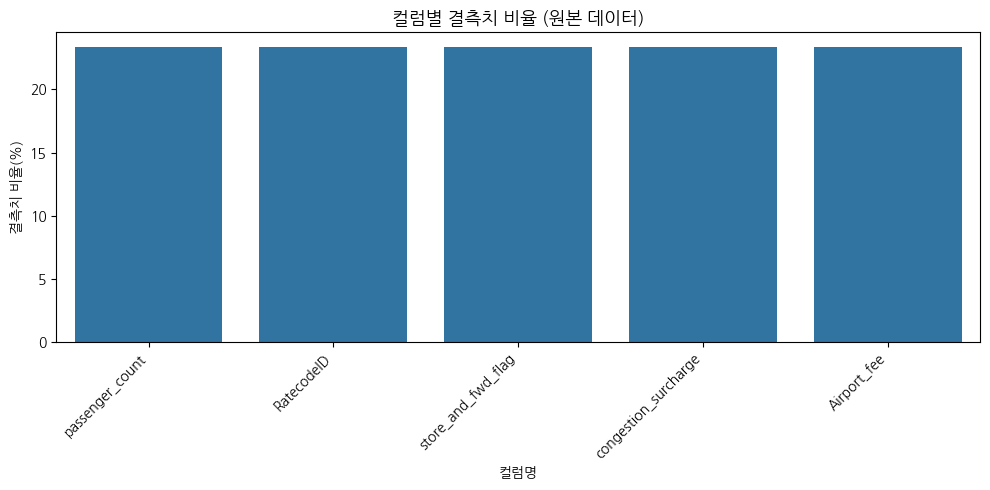

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'비율(%)': missing_pct})
missing_df = missing_df[missing_df['비율(%)'] > 0].sort_values('비율(%)', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=missing_df.index, y=missing_df['비율(%)'])
plt.title('컬럼별 결측치 비율 (원본 데이터)', fontsize=13)
plt.xlabel('컬럼명')
plt.ylabel('결측치 비율(%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

2. 주요 수치형 변수 이상치 시각화 — boxplot

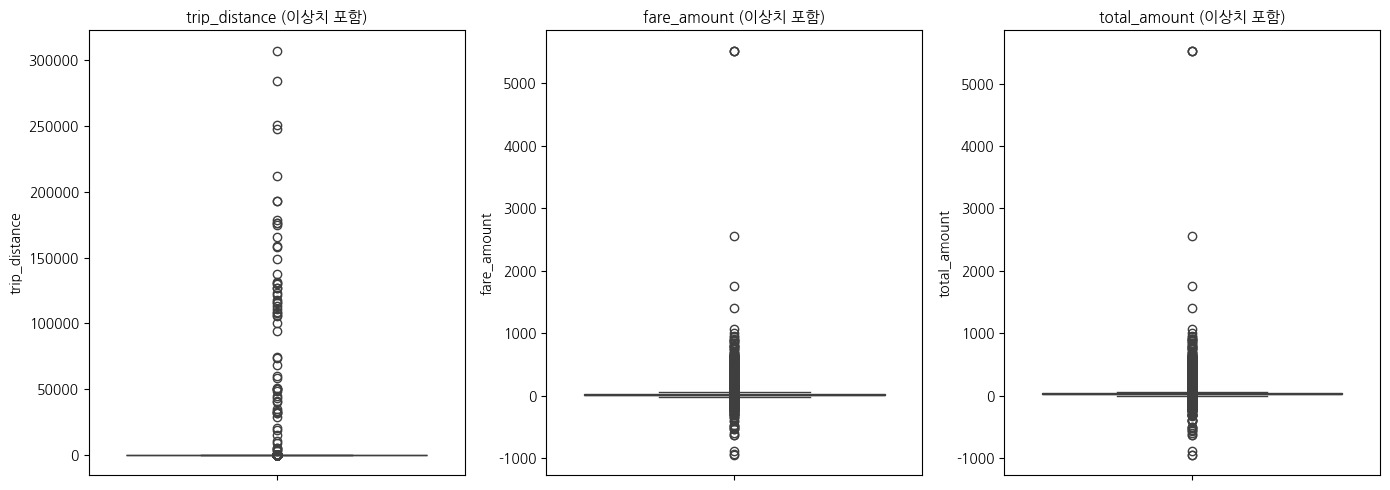

In [8]:
numeric_cols = ['trip_distance', 'fare_amount', 'total_amount']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(14,5))
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'{col} (이상치 포함)', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
3. 거리 vs 요금 관계 — Plotly scatter

In [9]:
import plotly.express as px

sample = df.sample(20000, random_state=42)

fig = px.scatter(
    sample, x='trip_distance', y='total_amount',
    title='운행거리와 총요금의 관계',
    labels={'trip_distance':'운행거리 (마일)', 'total_amount':'총요금 ($)'},
    opacity=0.4
)
fig.update_layout(title_x=0.5)
fig.show()

In [ ]:
4. 범주형 변수 이상치 탐지 시각화

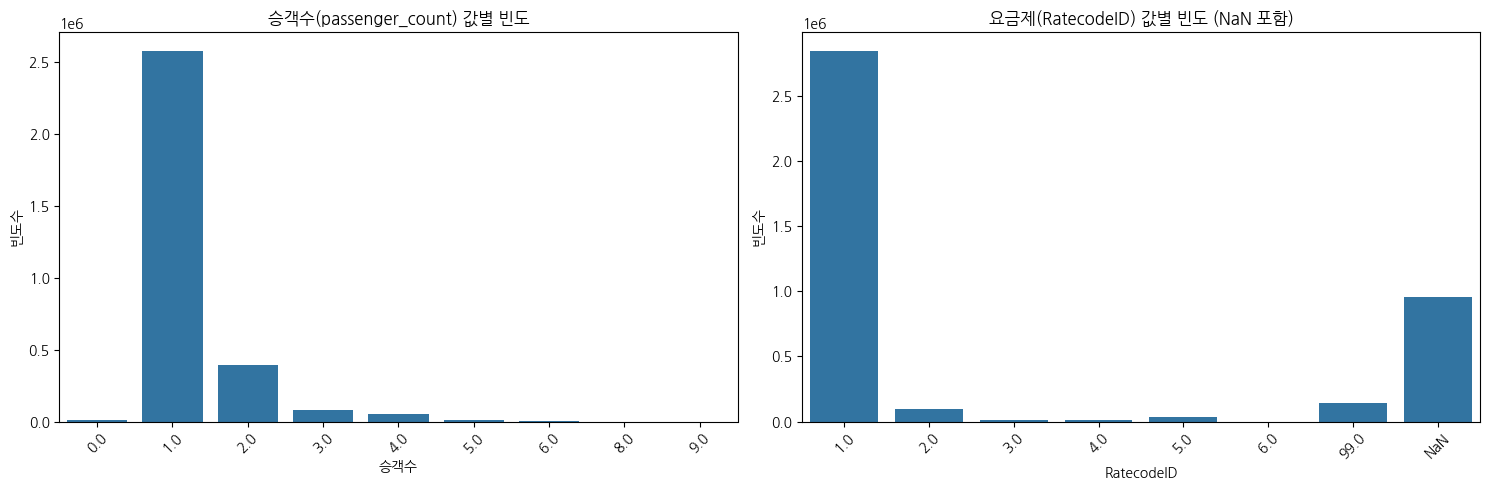

=== passenger_count 값 분포 ===
passenger_count
0.0      12533
1.0    2578718
2.0     395103
3.0      83959
4.0      52929
5.0       7666
6.0       4553
8.0          3
9.0          1
NaN     955371
Name: count, dtype: int64

=== RatecodeID 값 분포 (NaN 포함) ===
RatecodeID
1.0     2842930
2.0       95155
3.0       12567
4.0        8392
5.0       35523
6.0           1
99.0     140897
NaN      955371
Name: count, dtype: int64


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# =========================================================
# 범주형 변수 이상치 탐지: passenger_count, RatecodeID(NaN 포함)
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(15,5))

# ---- passenger_count 이상치 확인 ----
sns.countplot(x='passenger_count', data=df, ax=axes[0],
              order=sorted(df['passenger_count'].dropna().unique()))
axes[0].set_title('승객수(passenger_count) 값별 빈도', fontsize=12)
axes[0].set_xlabel('승객수')
axes[0].set_ylabel('빈도수')
axes[0].tick_params(axis='x', rotation=45)

# ---- RatecodeID 이상치 확인 (NaN 포함) ----
df_plot = df.copy()
df_plot['RatecodeID_display'] = df_plot['RatecodeID'].astype('object').fillna('NaN').astype(str)

order = sorted(df_plot['RatecodeID_display'].unique(),
               key=lambda x: (x=='NaN', float(x) if x!='NaN' else 0))

sns.countplot(x='RatecodeID_display', data=df_plot, ax=axes[1], order=order)
axes[1].set_title('요금제(RatecodeID) 값별 빈도 (NaN 포함)', fontsize=12)
axes[1].set_xlabel('RatecodeID')
axes[1].set_ylabel('빈도수')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_categorical_outliers.png', dpi=150)
plt.show()

# ---- 수치로 정확한 값 확인 ----
print("=== passenger_count 값 분포 ===")
print(df['passenger_count'].value_counts(dropna=False).sort_index())

print("\n=== RatecodeID 값 분포 (NaN 포함) ===")
print(df['RatecodeID'].value_counts(dropna=False).sort_index())